## Контрольная работа 4 Вариант 6

### Задача 1 Численное дифференцирование (1.5 балла)

Для заданной функции $e^x$ на интервале $[0 ; 2]$:

- Реализовать расчёт аппроксимации производной при заданном шаге $h$ двумя методами с первым и вторым порядком аппроксимации. Граничные точки должны вычисляться с тем же порядком аппроксимации.
- Построить графики ошибки вычисления от $n$ - числа подряд взятий производной вашими методами (как известно, $\frac{d e^x}{dx}=e^x$)
- Повторите предыдущий пункт для $e^{2x}$


In [20]:
import numpy as np

# Для первого порядка будем например брать правую разность (а для крайней правой точки придётся взять левую)
def diff_1(xs,ys):
    diffs = []
    for i in range(len(ys)):
        if i == len(ys)-1:
            diffs.append((ys[i]-ys[i-1])/(xs[i]-xs[i-1]))
        else:
            diffs.append((ys[i+1]-ys[i])/(xs[i+1]-xs[i]))
    return diffs

# Для второго порядка будем брать центральную разность, а для крайних точек правую и левую схемы второго порядка
def diff_2(xs, ys):
    diffs = []
    for i in range(len(ys)):
        if i == len(ys)-1:
            diffs.append((1/2*ys[i-2]-2*ys[i-1]+3/2*ys[i])/(xs[i]-xs[i-1]))
        elif i == 0:
            diffs.append(-1/2*ys[i+2]+2*ys[i+1]-3/2*ys[i]/(xs[i+1]-xs[i]))
        else:
            diffs.append((ys[i+1]-ys[i-1])/2/(xs[i]-xs[i-1]))
    return diffs

Ошибки для первого порядка:

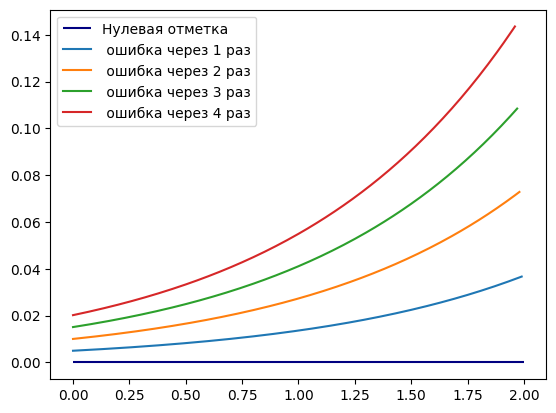

In [21]:
import matplotlib.pyplot as plt

h = 0.01
m=5

xs = np.linspace(0,2,int(2/h)+1)
ys = np.exp(xs)
plt.hlines(0, 0,2, label="Нулевая отметка", color="navy")
yi = ys
for i in range(1,m):
    yi = diff_1(xs,yi)
    plt.plot(xs[:-i], (yi-ys)[:-i], label=f" ошибка через {i} раз")

plt.legend()
plt.show()
    

Для второго порядка:

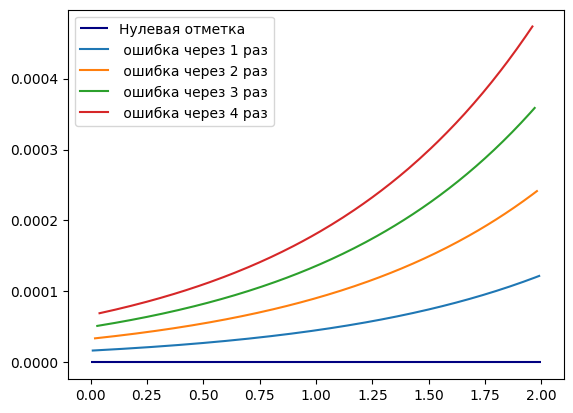

In [22]:
h = 0.01
m=5

xs = np.linspace(0,2,int(2/h)+1)
ys = np.exp(xs)
plt.hlines(0, 0,2, label="Нулевая отметка", color="navy")
yi = ys
for i in range(1,m):
    yi = diff_2(xs,yi)
    plt.plot(xs[i:-i], (yi-ys)[i:-i], label=f" ошибка через {i} раз")

plt.legend()
plt.show()

Теперь то же самое для $e^{2x}$

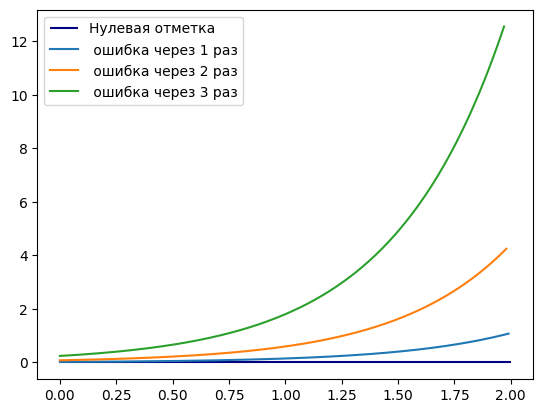

In [23]:
import matplotlib.pyplot as plt

h = 0.01
m=4

xs = np.linspace(0,2,int(2/h)+1)
ys = np.exp(2*xs)
plt.hlines(0, 0,2, label="Нулевая отметка", color="navy")
yi = ys
for i in range(1,m):
    yi = diff_1(xs,yi)
    plt.plot(xs[:-i], (yi-2**i*ys)[:-i], label=f" ошибка через {i} раз")

plt.legend()
plt.show()

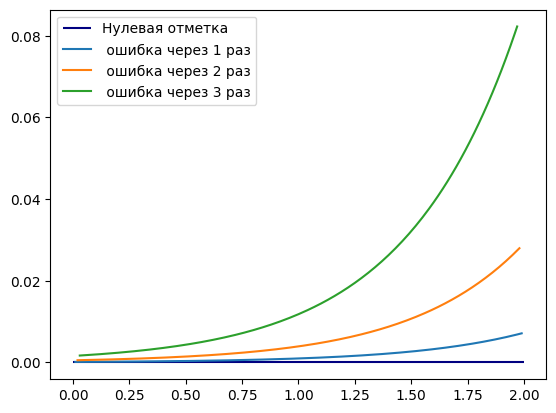

In [24]:
h = 0.01
m=4

xs = np.linspace(0,2,int(2/h)+1)
ys = np.exp(2*xs)
plt.hlines(0, 0,2, label="Нулевая отметка", color="navy")
yi = ys
for i in range(1,m):
    yi = diff_2(xs,yi)
    plt.plot(xs[i:-i], (yi-2**i*ys)[i:-i], label=f" ошибка через {i} раз")

plt.legend()
plt.show()

### Задача 2  Численное интегрирование (4 балла)

Для функции $f(x)=\cfrac{\cos x}{2+\sin x}$ вычислить определённый интеграл на отрезке $[2 ; 8]$ 

- Точно, аналитически взяв интеграл (можно использовать sympy).
<br />
- По формулам прямоугольников, трапеций и Симпсона при $n=12$ разбиении отрезка интегрирования.
<br />
- Вычислить абсолютную и относительную погрешность по априорным формулам для всех случаев п. 2.
<br />
- Вычислить абсолютную и относительную погрешность по формуле Рунге для всех случаев п. 2:

$$
\cfrac{\left|y_{i, h}-y_{i, h / 2}\right|}{2^p-1}  
$$

p - порядок точности использованного численного метода.

С помощью SymPy

In [25]:
from sympy import *
init_printing(use_unicode=False)
x = Symbol('x')
I = integrate(cos(x)/(2+sin(x)), (x,2,8))
print(I)

I_val = float(I)

print(I_val)

-log(sin(2) + 2) + log(sin(8) + 2)
0.027147113176278603


Прямоугольниками, трапециями и Симпсоном

In [26]:
import numpy as np
from scipy.integrate import trapezoid, simpson
n = 12

xs = np.linspace(2,8,n+1)
ys = np.cos(xs)/(2+np.sin(xs))

def I_rect(xs, ys):
    I = 0
    for i in range(len(xs)-1):
        val = (ys[i]+ys[i+1])/2
        I+= val*(xs[i+1]-xs[i])
    return I

I_r = I_rect(xs, ys)
I_trap = trapezoid(ys, xs)
I_simp = simpson(y = ys,x = xs)

print(I_r, I_trap, I_simp)

0.027141739870062492 0.02714173987006238 0.026102811853675092


Погрешности по аналитической формуле

In [27]:
# Найдены в Вольфраме
M_1 = 1
M_2 = 1.28179
M_4 = 9.8403

h = (8-2)/n
dI_r = (8-2)*h/2*M_1
dI_trap = (8-2)*h**2/12*M_2
dI_simp = (8-2)*h**4/180*M_4

# Абсолютные
print(dI_r, dI_trap, dI_simp)

# Относительные (НЕ в процентах)
print(dI_r/I_r, dI_trap/I_trap, dI_simp/I_simp)

1.5 0.16022375 0.020500624999999998
55.2654327681664 5.903223255659024 0.7853799473758094


Погрешности по Рунге

In [28]:
xs_double = np.linspace(2,8,n//2+1)
ys_double = np.cos(xs_double)/(2+np.sin(xs_double))

dI_r_runge = abs(I_rect(xs_double, ys_double)-I_r)/(2**1-1)
dI_trap_runge = abs(trapezoid(ys_double, xs_double)-I_trap)/(2**2-1)
dI_simp_runge = abs(simpson(y = ys_double, x = xs_double)-I_simp)/(2**4-1)

# Абсолютные
print(dI_r_runge, dI_trap_runge, dI_simp_runge)

# Относительные (НЕ в процентах)
print(dI_r_runge/I_r, dI_trap_runge/I_trap, dI_simp_runge/I_simp)

0.0031167840491619636 0.0010389280163873582 0.0037754041249158034
0.11483361288123595 0.038277870960413504 0.1446359168536953


### Задача 3  Интерполяция (2 балла)

Напишите функцию `my_cubic_spline(x, y, X)`, где x и y - массивы, содержащие точки экспериментальных данных, а X - массив. Предположим, что x и X расположены в порядке возрастания и имеют уникальные элементы. Выходной аргумент, Y, должен быть массивом того же размера, что и X, где Y[i] - __квадратичная сплайн-интерполяция__ в точке X[i]. Запрещается использовать interp1d или CubicSpline. Постройте график интерполяции на каких-нибудь данных.


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, solve

# Вообще по заданию нужна квадратичная сплайн-интерполяция, но уж функцию переименовывать не буду
def my_cubic_spline(x_data,y_data,x_new, plot):
    data = [[i,j] for i,j in zip(x_data,y_data)]
    points = np.array(data)
    n = len(points) - 1

    x, y = symbols('x, y')     #sympy
    a = symbols('a1:%d'%(n+1))
    b = symbols('b1:%d'%(n+1))
    c = symbols('c1:%d'%(n+1))


    ## list of quadratic functions 
    f = [a[i]*x**2 + b[i]*x + c[i] - y for i in range(n)]


    equations = []
    equations.append(f[0].subs(x, points[0, 0]).subs(y, points[0, 1]))

    # Generates quadratic equations at different points
    for i in range(n - 1):
        equations.append(f[i].subs(x, points[i + 1, 0]).subs(y, points[i + 1, 1]))
        equations.append(f[i + 1].subs(x, points[i + 1, 0]).subs(y, points[i + 1, 1]))

    equations.append(f[-1].subs(x, points[-1, 0]).subs(y, points[-1, 1]))


    # First derivatives of the equations
    fdx = [diff(fi, x) for fi in f]
    for i in range(n - 1):
        equations.append(fdx[i].subs(x, points[i + 1, 0]) - fdx[i + 1].subs(x, points[i + 1, 0]))


    equations.append(a[-1])

    equation_tuple = tuple(equations)
    coef_tuple = tuple(a+b+c)

    solution = solve(equation_tuple, coef_tuple)

    if plot:
        for i in range(n):
            span = np.linspace(points[i, 0], points[i + 1, 0], 100)
            fi = f[i].subs(solution)
            plt.plot(span, [solve(fi.subs(x, i)) for i in span], label='f{i}'.format(i=i+1))
        plt.scatter(points[:, 0], points[:, 1])


    y_new = []
    for x_p in x_new:
        for i in range(n):
            if x_p >= points[i,0] and x_p <= points[i+1,0]:
                fi=  f[i].subs(solution)
                yn = solve(fi.subs(x,x_p))[0]
                y_new.append(yn)
                plt.scatter(x_p, yn)
                break;
            else:
                yn = 0

    plt.grid()
    plt.legend()
    plt.show()
    return y_new


Пример работы

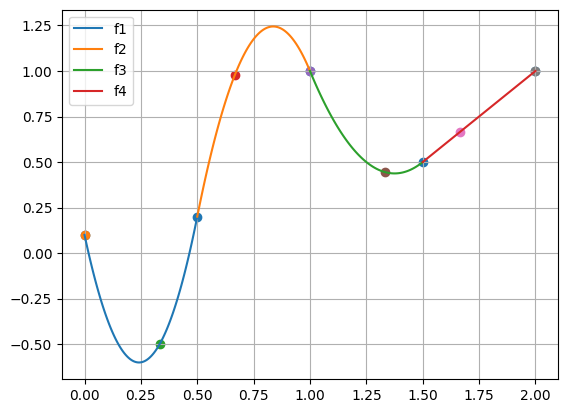

[0.100000000000000, -0.500000000000000, 0.977777777777778, 1.00000000000000, 0.444444444444444, 0.666666666666667, 1.00000000000000]


In [30]:
x_data = [0,0.5,1,1.5,2]
y_data = [0.1,0.2,1,0.5,1]

y_new = my_cubic_spline(x_data,y_data,x_new=np.linspace(0,2,7),plot=True)

print(y_new)

In [31]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

### Задача 4  Ряды (1 балл)

Найдите сумму ряда

$$
\sum_{n=0}^{\infty} \frac{(n+1)^2}{3^n}
$$

с точностью $\varepsilon=10^{-6}$. Обоснуйте, почему исходная точность достигнута.


Оценим величину остатка ряда: Сначала поймём, что начиная с некоторого $n_0$ (например 6) выполняется $$(n+1)^2 < 2^n,$$ так как показательная функци "забьёт" степенную, а значит остаток ряда $$R_k = \sum_{n=k}^{\infty} \frac{(n+1)^2}{3^n} < \sum_{n=k}^{\infty} \left( \dfrac{2}{3}\right)^n,$$ а это сумма геометрическое прогрессии, и тогда $$R_k < 3 \left( \dfrac{2}{3}\right)^k = \varepsilon$$ Отсюда находим $$k \approx 36.8$$

In [32]:
k = 37
s=0
for n in range(k):
    s+=(n+1)**2/3**n

print(s)

4.499999999999994


Действительно, точное значение суммы этого ряда $4.5$, и мы получили значение, соответствующее ему с требуемой точностью

### Задача 5  Дискретное преобразование Фурье (1.5 балла)

Сгенерируйте два сигнала: сигнал 1 - синусоидальная волна с частотой 5 Гц, амплитудой 3 и фазовым сдвигом 3; сигнал 2 - синусоидальная волна с частотой 2 Гц, амплитудой 2 и фазовым сдвигом -2. Постройте график суммы сигнала в течение 2 секунд. Сделайте дискретное преобразование Фурье. Как из него "вычленить" исходные сигналы?


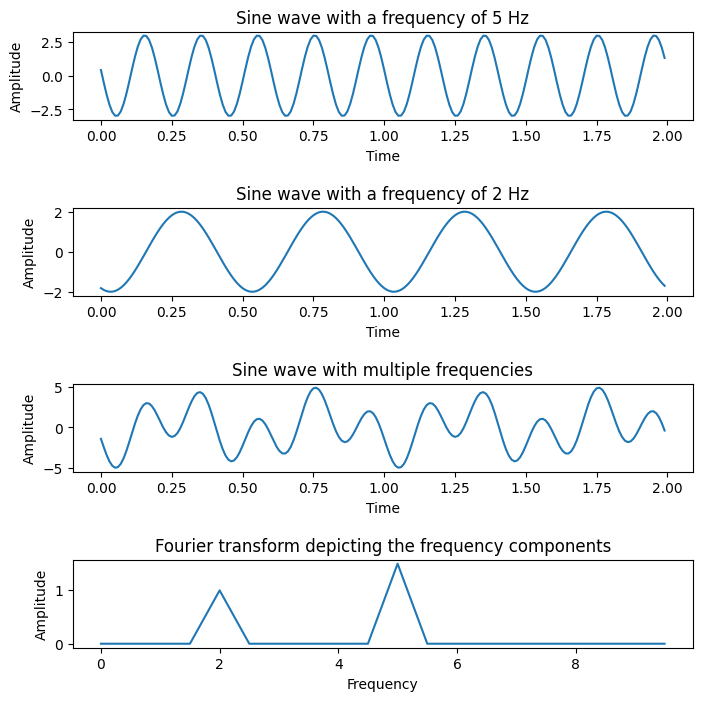

In [33]:
# Python example - Fourier transform using numpy.fft method

import numpy as np
import matplotlib.pyplot as plt

# How many time points are needed i,e., Sampling Frequency
samplingFrequency   = 100;

# At what intervals time points are sampled
samplingInterval       = 1 / samplingFrequency;

# Begin time period of the signals
beginTime           = 0;

# End time period of the signals
endTime             = 2;

# Frequency of the signals
signal1Frequency     = 5;
signal2Frequency     = 2;

# Time points
time        = np.arange(beginTime, endTime, samplingInterval);

# Create two sine waves
amplitude1 = 3*np.sin(2*np.pi*signal1Frequency*time + 3)
amplitude2 = 2*np.sin(2*np.pi*signal2Frequency*time - 2)

# Create subplot
figure, axis = plt.subplots(4, 1)
figure.set_size_inches(8, 8)
plt.subplots_adjust(hspace=1)

# Time domain representation for sine wave 1
axis[0].set_title('Sine wave with a frequency of 5 Hz')
axis[0].plot(time, amplitude1)
axis[0].set_xlabel('Time')
axis[0].set_ylabel('Amplitude')

# Time domain representation for sine wave 2
axis[1].set_title('Sine wave with a frequency of 2 Hz')
axis[1].plot(time, amplitude2)
axis[1].set_xlabel('Time')
axis[1].set_ylabel('Amplitude')

# Add the sine waves
amplitude = amplitude1 + amplitude2

# Time domain representation of the resultant sine wave
axis[2].set_title('Sine wave with multiple frequencies')
axis[2].plot(time, amplitude)
axis[2].set_xlabel('Time')
axis[2].set_ylabel('Amplitude')

# Frequency domain representation
fourierTransform = np.fft.fft(amplitude)/len(amplitude)           # Normalize amplitude !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
fourierTransform = fourierTransform[range(int(len(amplitude)/2))] # Берём только половину спектра из-за симметрии!!!!!

tpCount     = len(amplitude)

values      = np.arange(int(tpCount/2))

timePeriod  = tpCount/samplingFrequency

frequencies = values/timePeriod

# Frequency domain representation
axis[3].set_title('Fourier transform depicting the frequency components')
axis[3].plot(frequencies[:20], abs(fourierTransform)[:20])
axis[3].set_xlabel('Frequency')
axis[3].set_ylabel('Amplitude')

plt.show()

Вычленить элементарные сигналы можем, проведя обратное Фурье-преобразование, но занулив все остальные частоты (в смысле кроме той частоты, сигнал на которой хотим восстановить)

c:\Users\Dmitriy Makarov\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Dmitriy Makarov\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


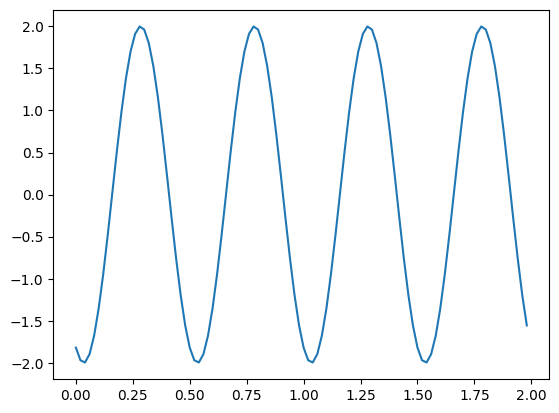

In [34]:
from scipy.fft import ifft

freq_1 = np.concatenate([np.zeros(4), [fourierTransform[4]], np.zeros(len(fourierTransform)-5)])
s1 = ifft(freq_1)*len(amplitude)

plt.plot(time[::2], s1)
plt.show()

Получили в точности один из наших изначальных сигналов 

Аналогично и со второй частотой

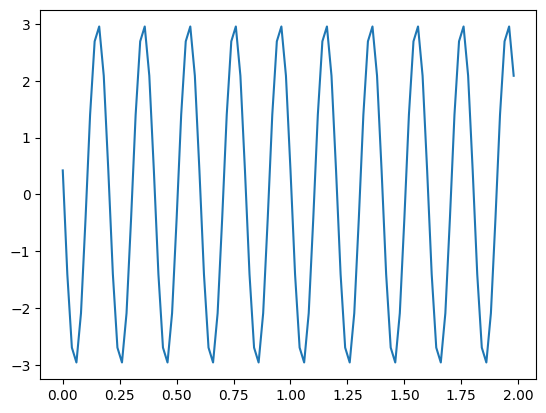

In [35]:
from scipy.fft import ifft

freq_2 = np.concatenate([np.zeros(10), [fourierTransform[10]], np.zeros(len(fourierTransform)-11)])
s2 = ifft(freq_2)*len(amplitude)

plt.plot(time[::2], s2)